In [1]:
#import the packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

#Load the Dataset
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names
target_names = data.target_names

print(f"Dataset loaded: {X.shape[0]} samples, {X.shape[1]} features.")
print(f"Target classes: {target_names}")

# Split the data into training and testing sets as 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y # stratify ensures balanced classes
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Dataset loaded: 569 samples, 30 features.
Target classes: ['malignant' 'benign']
Training set size: 398
Testing set size: 171


In [6]:
#model training
# max_depth=5 to limit the complexity and make the tree visualization readable.
model = DecisionTreeClassifier(max_depth=5, random_state=1)
model.fit(X_train, y_train)

# Make Predictions and Evaluate
y_pred = model.predict(X_test)

print("DECISION TREE MODEL EVALUATION ")

# Accuracy and Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

# 2. Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)



DECISION TREE MODEL EVALUATION 

Classification Report:
              precision    recall  f1-score   support

   malignant       0.91      0.94      0.92        64
      benign       0.96      0.94      0.95       107

    accuracy                           0.94       171
   macro avg       0.94      0.94      0.94       171
weighted avg       0.94      0.94      0.94       171


Confusion Matrix:
[[ 60   4]
 [  6 101]]


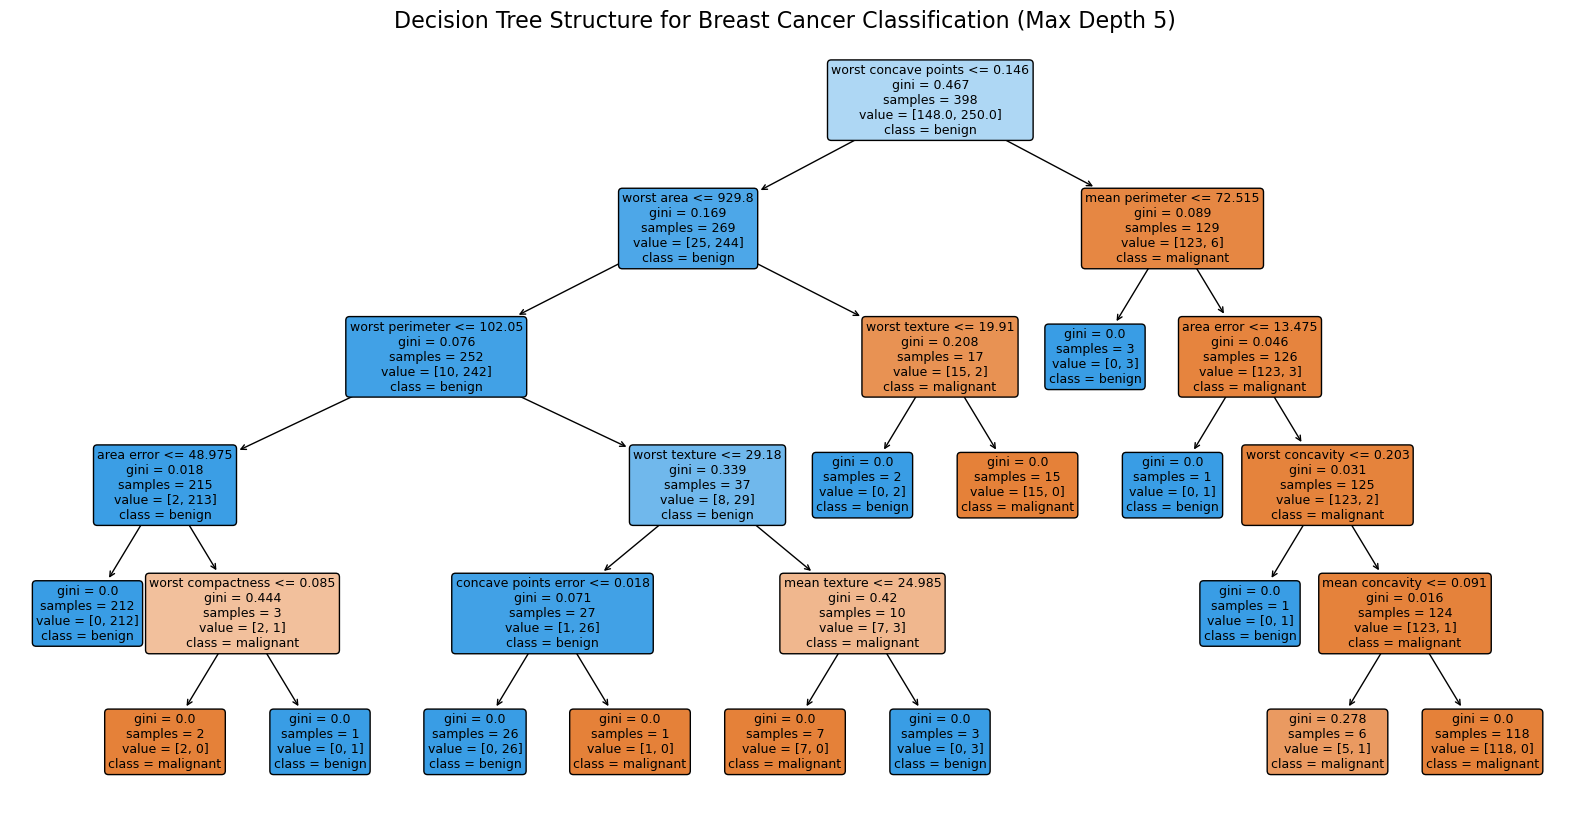

In [3]:
# Visualize the Decision Tree Model
plt.figure(figsize=(20, 10))
plot_tree(
    model, 
    feature_names=feature_names,
    class_names=target_names,
    filled=True, 
    rounded=True,
    fontsize=9
)
plt.title("Decision Tree Structure for Breast Cancer Classification (Max Depth 5)", fontsize=16)
plt.show()

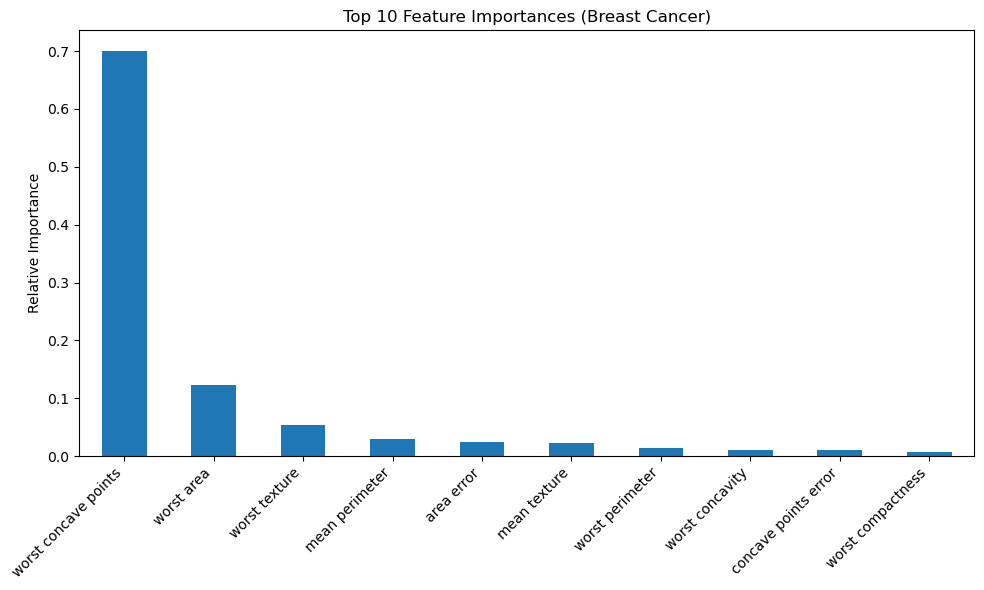

In [5]:
# Analyze Feature Importance
importance = model.feature_importances_
feature_series = pd.Series(importance, index=feature_names)
feature_series = feature_series.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_series.head(10).plot(kind='bar')
plt.title("Top 10 Feature Importances (Breast Cancer)")
plt.ylabel("Relative Importance")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

